# Diffusion Models on a 2D Swiss Roll

We learn a simple idea: if we can add noise to data and then learn how to
remove it step by step, we can generate new data. This notebook shows the
core of diffusion models on a 2D toy dataset.

Key idea:
- Forward: we step by step corrupt data $x_0$ into pure noise $x_T$.
- Reverse: we learn to denoise $x_t \to x_{t-1}$ using a small network.
- Training: the network predicts the noise we added (easier than predicting
  the clean data).

External resources:
- [Very good video visualizing diffusion models](https://youtu.be/iv-5mZ_9CPY?si=6pWf5M3a08duvH-a)
- [Original DDPM paper](https://arxiv.org/pdf/2006.11239)

See examples and try them
- Stable Diffusion (open-source ecosystem)
  - Website: https://stable-diffusion-art.com/ (guides and galleries)
  - Hugging Face models: https://huggingface.co/CompVis and https://huggingface.co/stabilityai
- Midjourney (commercial, Discord-based)
  - Website: https://www.midjourney.com/
- DALL·E (OpenAI)
  - DALL·E 3 overview: https://openai.com/research/dall-e-3

![diffusion](https://images.ctfassets.net/kftzwdyauwt9/1uXIgnK3ezRwBVmLmr6LhV/8d76002753557244109c3395eb5c774d/basketball3.png?w=3840&q=90&fm=webp)

### Setup and Imports

**Instructor note:** Just run this cell, you can ignore the code details.

In [1]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_swiss_roll


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Why the Swiss Roll

- It is a simple 2D structure that is clearly not a blob.
- If our generated samples match this spiral shape, the model learned real
  structure, not just noise.
- We normalize data so the model does not have to deal with large numbers.

### Data and plotting helpers

**Instructor note:** Just run this cell, you can ignore the code details.

In [2]:
class SwissRoll2D(Dataset):
    """
    Create a 2D Swiss Roll by taking (x, z) from the 3D Swiss roll.
    Optionally normalize each axis to have mean 0 and std 1.
    """

    def __init__(self, num_samples=10000, noise=0.05, normalize=True):
        data3d, _ = make_swiss_roll(n_samples=num_samples, noise=noise)
        xz = data3d[:, [0, 2]].astype(np.float32)
        x = torch.from_numpy(xz)
        if normalize:
            mu = x.mean(dim=0, keepdim=True)
            std = x.std(dim=0, keepdim=True).clamp_min(1e-6)
            x = (x - mu) / std
        self.data = x

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, i):
        return self.data[i]


def data_limits(x, pad=0.1):
    x_np = x.detach().cpu().numpy()
    xmin, ymin = x_np.min(axis=0)
    xmax, ymax = x_np.max(axis=0)
    xr = xmax - xmin
    yr = ymax - ymin
    return xmin - pad * xr, xmax + pad * xr, ymin - pad * yr, ymax + pad * yr


def plot_points(x, title="Points", s=5, limits=None, figsize=(5, 5)):
    x_np = x.detach().cpu().numpy()
    if limits is None:
        limits = data_limits(x, pad=0.1)
    xmin, xmax, ymin, ymax = limits
    plt.figure(figsize=figsize)
    plt.scatter(x_np[:, 0], x_np[:, 1], s=s, alpha=0.7)
    plt.title(title)
    ax = plt.gca()
    ax.set_aspect("equal", "box")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(alpha=0.2)
    plt.show()


def plot_forward_grid(model, x0, steps, cols=3, title="Forward (simple)"):
    x0 = x0.to(model.device)
    B = min(2000, x0.size(0))
    idx = torch.randperm(x0.size(0), device=model.device)[:B]
    x0_sub = x0[idx]

    xmin, xmax, ymin, ymax = data_limits(x0_sub, pad=0.1)
    steps = [int(s) for s in steps if 0 <= int(s) < model.T]
    panels = [("t = 0", x0_sub.cpu().numpy())]
    for tval in steps:
        tt = torch.full((B,), tval, device=model.device, dtype=torch.long)
        xt = model.q_sample(x0_sub, tt)
        panels.append((f"t = {tval}", xt.cpu().numpy()))

    rows = math.ceil(len(panels) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, (label, pts) in enumerate(panels, start=1):
        plt.subplot(rows, cols, i)
        plt.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.7)
        plt.title(label)
        ax = plt.gca()
        ax.set_aspect("equal", "box")
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)
        plt.grid(alpha=0.2)
    plt.suptitle(title)
    plt.show()


def plot_reverse_grid(model, steps, ref_points, n_show=3000, cols=3, title="Reverse"):
    steps = [int(s) for s in steps if 0 <= int(s) < model.T]
    if 0 not in steps:
        steps.append(0)
    steps = sorted(set(steps), reverse=True)

    n = max(n_show, 2000)
    _, snaps = model.sample(n=n, step_size=1, eta=1.0, collect_ts=steps)

    xmin, xmax, ymin, ymax = data_limits(ref_points, pad=0.1)
    rows = math.ceil(len(steps) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, tval in enumerate(steps, start=1):
        x_t = snaps[tval][:n_show].cpu().numpy()
        plt.subplot(rows, cols, i)
        plt.scatter(x_t[:, 0], x_t[:, 1], s=5, alpha=0.7)
        plt.title(f"t = {tval}")
        ax = plt.gca()
        ax.set_aspect("equal", "box")
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)
        plt.grid(alpha=0.2)
    plt.suptitle(title)
    plt.show()

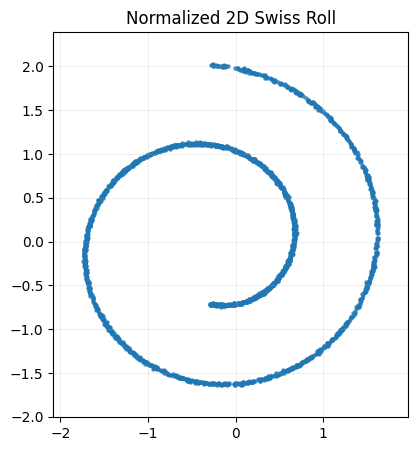

In [3]:
# Build dataset and loader
BATCH_SIZE = 256
dataset = SwissRoll2D(num_samples=10000, noise=0.05, normalize=True)
loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                    shuffle=True, drop_last=True)

# Peek at the dataset
with torch.no_grad():
    idx = torch.randperm(len(dataset))[:2000]
    plot_points(dataset.data[idx], title="Normalized 2D Swiss Roll")

### Exercise 1
Task: add acttivation function + extra hidden before final layer.

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            # Task: Implement here a neural network
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t_norm):
        h = torch.cat([x, t_norm], dim=1)
        return self.net(h)


# Tiny helper: normalize integer time t to [0, 1]
def t_to_norm(t: torch.Tensor, T: int) -> torch.Tensor:
    if t.dim() == 0:
        t = t.view(1)
    return (t.float() / max(T - 1, 1)).unsqueeze(1)  # (B, 1)

<details>
  <summary>Click to see the solution</summary>

  ```python
  nn.SiLU(),
  nn.Linear(hidden, hidden),
  nn.SiLU(),
  ```
</details>

## Part A: SimpleDiffusion
**Idea:**  
We create a simple denoising process where the model learns how to reverse one small step of noise at a time.

**Forward (noising):**  
- Starting from a clean point $x_0$, we repeatedly mix it with random noise:
  $$
    x_{t+1} = (1-\beta)x_t + \beta\,\epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
  $$
- Each step adds a little more noise; after many steps, the data becomes random.

**Training (residual prediction):**  
- Given a noised sample $x_t$ and time $t$, the model tries to predict how to recover $x_{t-1}$ from $x_t$.
- It learns a small residual $r(x_t, t)$ so that:
  $$
    x_{t-1} \approx x_t - r(x_t, t)
  $$
- We use mean squared error to train the network to make this correction as accurate as possible.

**Reverse (sampling):**  
- Starting from random noise, the model applies its learned correction step by step, slowly reconstructing new samples that look like the original data.

### Exercise 2

- Fill in the missing code in the `step_forward` method

In [6]:
class SimpleDiffusion(nn.Module):
    """
    Very simple iterative denoiser:
      - Forward: x_{t+1} = (1 - beta) * x_t + beta * N(0, I)
      - Train: learn residual r(xt, t) to predict x_{t-1} from x_t
      - Sample: start from noise and apply x = x - r(x, t)
    """

    def __init__(self, T=10, beta=0.12, hidden=64, device=None): ## important!
        super().__init__()
        self.T = int(T)
        self.beta = float(beta)
        self.device = device if device is not None else torch.device("cpu")
        self.net = MLP(hidden=hidden)

    def forward(self, x_t, t):
        if t.dim() == 0:
            t = t.expand(x_t.shape[0])
        t_norm = t_to_norm(t, self.T)
        return self.net(x_t, t_norm)  # residual (B, 2)

    @torch.no_grad()
    def step_forward(self, x):
        noise = torch.randn_like(x)
        # Exercise 2: write the mixing line
        # Forward: x_{t+1} = (1 - beta) * x_t + beta * N(0, I)
        # TODO: x_next = ...
        x_next = (1.0 - self.beta) * x + self.beta * noise
        return x_next

    @torch.no_grad()
    def q_sample(self, x0, t, eps=None):
        # Iterate 't' forward steps. Assumes uniform t across the batch.
        steps = int(t[0].item()) if t.dim() > 0 else int(t.item())
        x = x0.clone()
        for _ in range(steps):
            x = self.step_forward(x)
        return x

    @torch.no_grad()
    def sample(self, n, step_size=1.0, eta=0.0, collect_ts=None):
        # step_size and eta are unused; kept for compatibility with plotting helpers.
        x = torch.randn(n, 2, device=self.device)
        snaps = {}

        for t_int in reversed(range(self.T)):
            t_vec = torch.full(
                (n,), t_int, device=self.device, dtype=torch.long)
            resid = self.forward(x, t_vec)
            x = x - resid
            if collect_ts is not None and t_int in collect_ts:
                snaps[t_int] = x.detach().clone()

        snaps[0] = x.detach().clone()
        return x, snaps

<details>
  <summary>Click to see the solution</summary>

  ```python
  x_next = (1.0 - self.beta) * x + self.beta * noise
  ```
</details>

## Visualize forward noising for the toy model

- Shows how repeated noising turns the spiral into a blob.

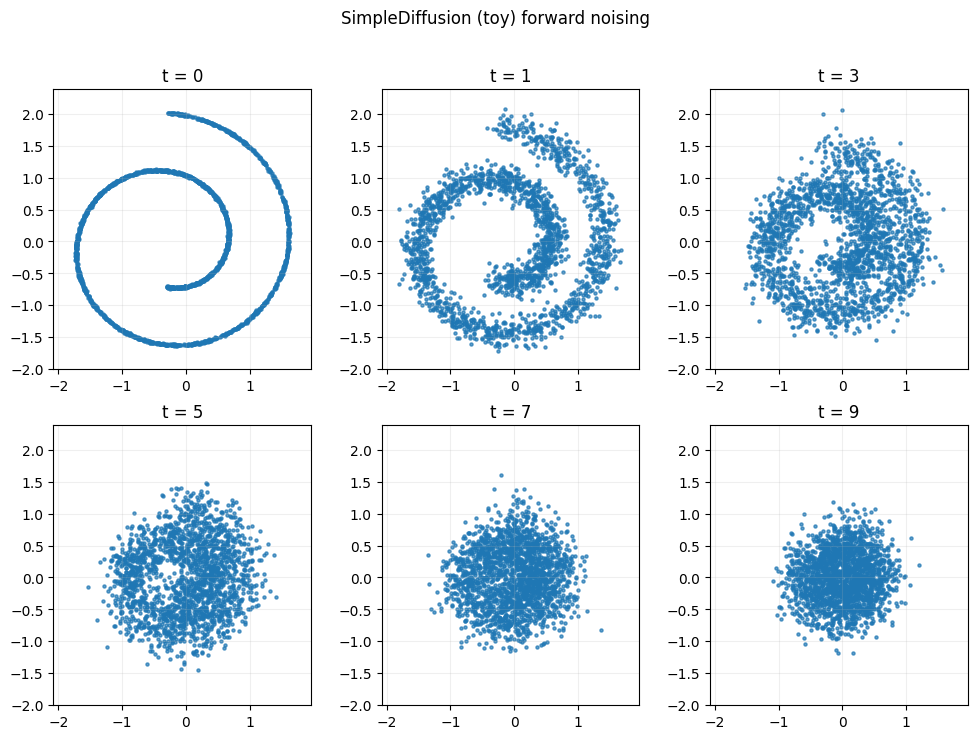

In [7]:
toy_T = 10
toy_model = SimpleDiffusion(
    T=toy_T, beta=0.12, hidden=64, device=device).to(device)

with torch.no_grad():
    plot_forward_grid(
        toy_model,
        dataset.data,
        steps=[1, 3, 5, 7, 9],
        cols=3,
        title="SimpleDiffusion (toy) forward noising",
    )

### Train the toy model

- Build the noised trajectory $x_0, \ldots, x_T$ once per batch.
- Train to predict $x_{t-1}$ from $x_t$ by learning a residual $r(x_t, t-1)$.
- We loop over $t$ for clarity; $T$ is small so it runs fast.
- Instructor note: You can skim the loop.

### Exercise 3

In [8]:
TOY_EPOCHS = 200
optimizer = torch.optim.Adam(toy_model.parameters(), lr=1e-3)
toy_losses = []

toy_model.train()
for epoch in range(1, TOY_EPOCHS + 1):
    running, batches = 0.0, 0

    for x0 in loader:
        x0 = x0.to(device)
        bsz = x0.size(0)

        # Build forward trajectory once: x_0, x_1, ..., x_T
        xts = [x0]
        for _ in range(toy_model.T):
            xts.append(toy_model.step_forward(xts[-1]))

        total_loss = 0.0
        for t in reversed(range(1, toy_model.T + 1)):
            xt = xts[t]
            x_prev = xts[t - 1]

            t_vec = torch.full((bsz,), t - 1, device=device, dtype=torch.long)
            resid = toy_model(xt, t_vec)
            # EX 3: Predict residual
            # We learn a residual r(x_t, t) so that x_{t-1} ~ x_t - r(x_t, t)
            # TODO: x_prev_pred = ?
            x_prev_pred = xt - resid
            # We compare our prediction to the true x_{t-1}
            # TODO: loss = F.mse_loss()   # fill args
            loss = F.mse_loss(x_prev_pred, x_prev)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        running += total_loss / toy_model.T
        batches += 1

    avg = running / max(batches, 1)
    toy_losses.append(avg)
    if epoch % 25 == 0 or epoch == 1:
        print(f"[Toy] Epoch {epoch:3d}/{TOY_EPOCHS} | loss: {avg:.5f}")

[Toy] Epoch   1/200 | loss: 0.01787
[Toy] Epoch  25/200 | loss: 0.01697
[Toy] Epoch  50/200 | loss: 0.01685
[Toy] Epoch  75/200 | loss: 0.01639
[Toy] Epoch 100/200 | loss: 0.01610
[Toy] Epoch 125/200 | loss: 0.01600
[Toy] Epoch 150/200 | loss: 0.01593
[Toy] Epoch 175/200 | loss: 0.01598
[Toy] Epoch 200/200 | loss: 0.01596


<details>
  <summary>Click to see the solution</summary>

  ```python
  x_prev_pred = xt - resid
  loss = F.mse_loss(x_prev_pred, x_prev)
  ```
</details>

### Reverse visualization and samples for the toy model

- Watch denoising unfold and compare generated samples to the dataset.

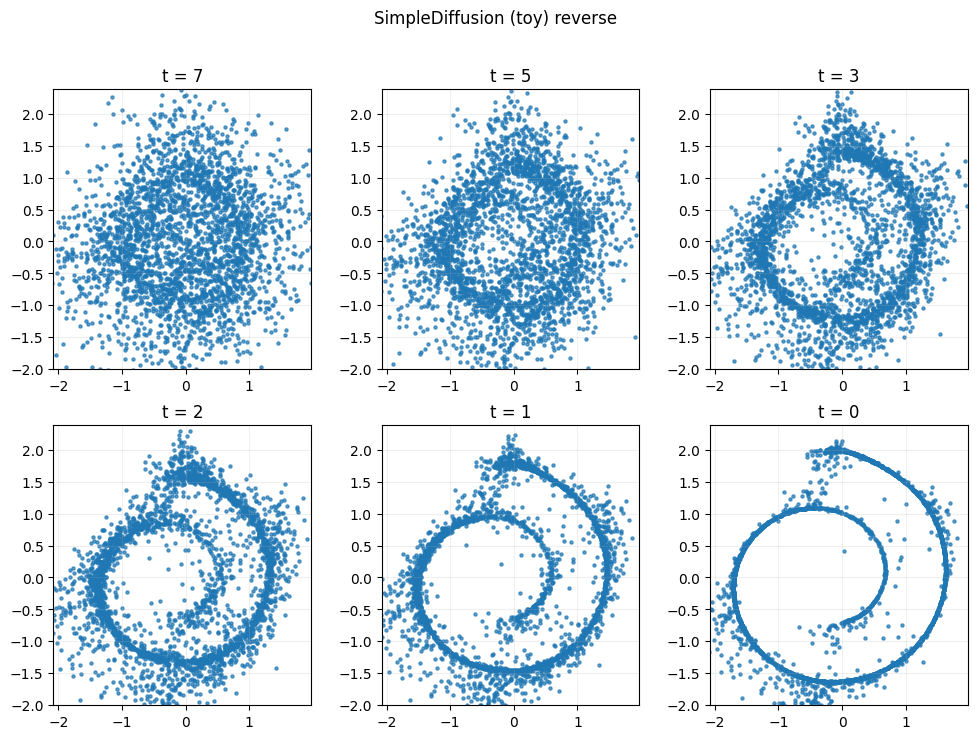

In [9]:
toy_model.eval()

plot_reverse_grid(
    toy_model,
    steps=[1, 2, 3, 5, 7],
    ref_points=dataset.data,
    n_show=3000,
    cols=3,
    title="SimpleDiffusion (toy) reverse",
)

## Part B: DDPM ( Denoising Diffusion Probabilistic Model )

This is more advanced and closer to real diffusion models used in practice.


Idea
- We corrupt data with Gaussian noise whose strength grows over time. If we can learn to predict that noise from a noisy sample and its time index, we can subtract it step by step to recover data.

Forward (noising)
- We create noisy points by
  $x_t = x_0 + \sigma(t)\,\epsilon$, with $\epsilon \sim \mathcal{N}(0, I)$.
- The schedule $\sigma(t)$ increases from 0 to $\sigma_{\max}$, so later steps are noisier.

Training (noise prediction)
- Input: a noisy sample $x_t$ and its time $t$.
- Target: the exact noise $\epsilon$ used to make $x_t$.
- Loss: mean squared error between predicted and true noise.
- Why predict $\epsilon$: it keeps targets well-scaled across timesteps and stabilizes learning compared to predicting $x_0$ directly.

Reverse (sampling / denoising)
- Start from pure noise and iterate from $t=T-1$ down to 0.
- At each step, predict noise $\hat{\epsilon}(x_t, t)$ and move a bit toward denoised samples:
  $$\text{mean\_step} = x_t - \text{step\_size}\cdot\sigma(t)\cdot\hat{\epsilon}$$
- Add optional randomness:
  $x_{t-1} = \text{mean\_step} + \text{eta}\cdot\sigma(t)\cdot z$, with $z \sim \mathcal{N}(0, I)$.
  - step_size controls how aggressively we denoise each step.
  - eta controls sample diversity (0 = deterministic, larger values = more variety).

### Exercise 4

In [10]:
class DDPM(nn.Module):
    """
    Minimal diffusion-like model for 2D points that predicts epsilon.
      - Forward: x_t = x_0 + sigma(t) * eps
      - Train: predict eps from (x_t, t) via MSE
      - Sample: iterative denoising with step_size and eta
    """

    def __init__(self, T=100, sigma_max=1.5, hidden=128, device=None):
        super().__init__()
        self.T = int(T)
        self.sigma_max = float(sigma_max)
        self.device = device if device is not None else torch.device("cpu")
        self.net = MLP(hidden=hidden)

    def sigma(self, t):
        if t.dim() == 0:
            t = t.view(1)
        t_norm = t.float() / max(self.T - 1, 1)
        return (t_norm * self.sigma_max).unsqueeze(1)  # (B, 1)

    def forward(self, x_t, t):
        if t.dim() == 0:
            t = t.expand(x_t.shape[0])
        t_norm = t_to_norm(t, self.T)
        return self.net(x_t, t_norm)  # predicted eps (B, 2)

    @torch.no_grad()
    def q_sample(self, x0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(x0)
        sig = self.sigma(t)  # (B, 1)
        return x0 + sig * eps

    @torch.no_grad()
    def sample(self, n, step_size=0.5, eta=0.8, collect_ts=None):
        x = torch.randn(n, 2, device=self.device) * self.sigma_max
        snaps = {}

        for t_int in reversed(range(self.T)):
            t_vec = torch.full((n,), t_int, device=self.device, dtype=torch.long)
            eps_pred = self.forward(x, t_vec)
            sig = self.sigma(t_vec)
            # Exercise 4 — Mean step in DDPM.sample
            # TODO: mean_step = ...
            mean_step = x - step_size * sig * eps_pred
            if eta > 0.0 and t_int > 0:
                z = torch.randn_like(x)
                x = mean_step + eta * sig * z
            else:
                x = mean_step

            if collect_ts is not None and t_int in collect_ts:
                snaps[t_int] = x.detach().clone()

        snaps[0] = x.detach().clone()
        return x, snaps

<details>
  <summary>Click to see the solution</summary>

  ```python
  mean_step = x - step_size * sig * eps_pred
  ```
</details>

### Visualize forward noising for DDPM

- As $t$ increases, points spread out. We use $\sigma(t)$ increasing linearly from 0 to $\sigma_{\max}$.

DDPM params: 17282


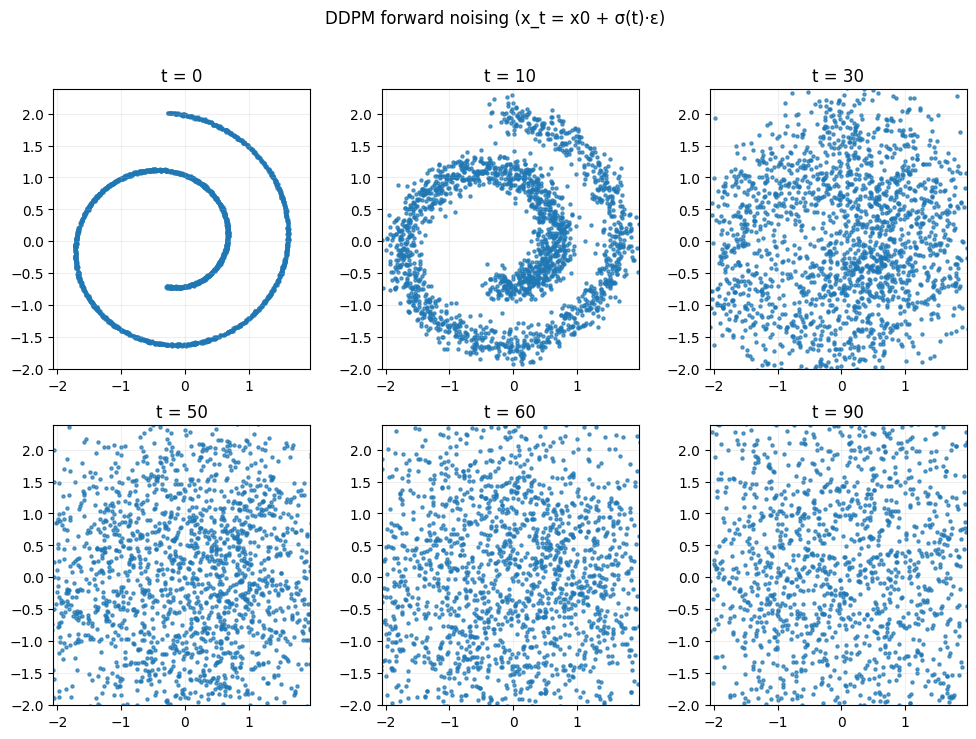

In [11]:
T_ddpm = 100
model = DDPM(T=T_ddpm, sigma_max=1.5, hidden=128, device=device).to(device)
print("DDPM params:", sum(p.numel()
      for p in model.parameters() if p.requires_grad))

with torch.no_grad():
    plot_forward_grid(
        model,
        dataset.data,
        steps=[10, 30, 50, 60, 90],
        cols=3,
        title="DDPM forward noising (x_t = x0 + σ(t)·ε)",
    )

### Train DDPM to predict $\epsilon$

- Sample a random $t$ per example.
- Create $x_t = x_0 + \sigma(t)\,\epsilon$.
- Predict $\epsilon$ and minimize MSE.
- Instructor note: You can skim the loop.
- **Instructor note:** Just run this cell, you can ignore the code details.

Epoch   1/800 | loss: 0.72533
Epoch  50/800 | loss: 0.61487
Epoch 100/800 | loss: 0.62382
Epoch 150/800 | loss: 0.59901
Epoch 200/800 | loss: 0.58310
Epoch 250/800 | loss: 0.56362
Epoch 300/800 | loss: 0.56515
Epoch 350/800 | loss: 0.55094
Epoch 400/800 | loss: 0.55198
Epoch 450/800 | loss: 0.55417
Epoch 500/800 | loss: 0.55175
Epoch 550/800 | loss: 0.55835
Epoch 600/800 | loss: 0.55417
Epoch 650/800 | loss: 0.54071
Epoch 700/800 | loss: 0.55535
Epoch 750/800 | loss: 0.55959
Epoch 800/800 | loss: 0.55133


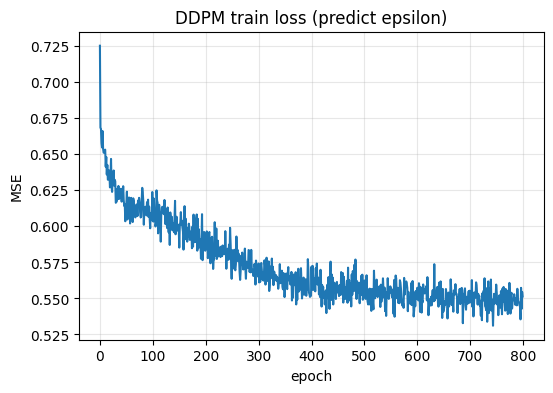

In [12]:
EPOCHS = 800  # reduce if on CPU
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loss = []

model.train()
for epoch in range(1, EPOCHS + 1):
    running, batches = 0.0, 0

    for x0 in loader:
        x0 = x0.to(device)
        bsz = x0.size(0)

        t = torch.randint(0, model.T, (bsz,), device=device, dtype=torch.long)
        eps = torch.randn_like(x0)
        x_t = model.q_sample(x0, t, eps)

        eps_pred = model(x_t, t)
        loss = F.mse_loss(eps_pred, eps)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item()
        batches += 1

    avg = running / max(batches, 1)
    train_loss.append(avg)
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | loss: {avg:.5f}")

# Plot the training curve
plt.figure(figsize=(6, 4))
plt.plot(train_loss)
plt.title("DDPM train loss (predict epsilon)")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.show()

### Reverse visualization and samples for DDPM

- Start from noise and denoise step by step.
- $\text{step\_size}$ controls how boldly we move; $\text{eta}$ controls randomness in the reverse process.

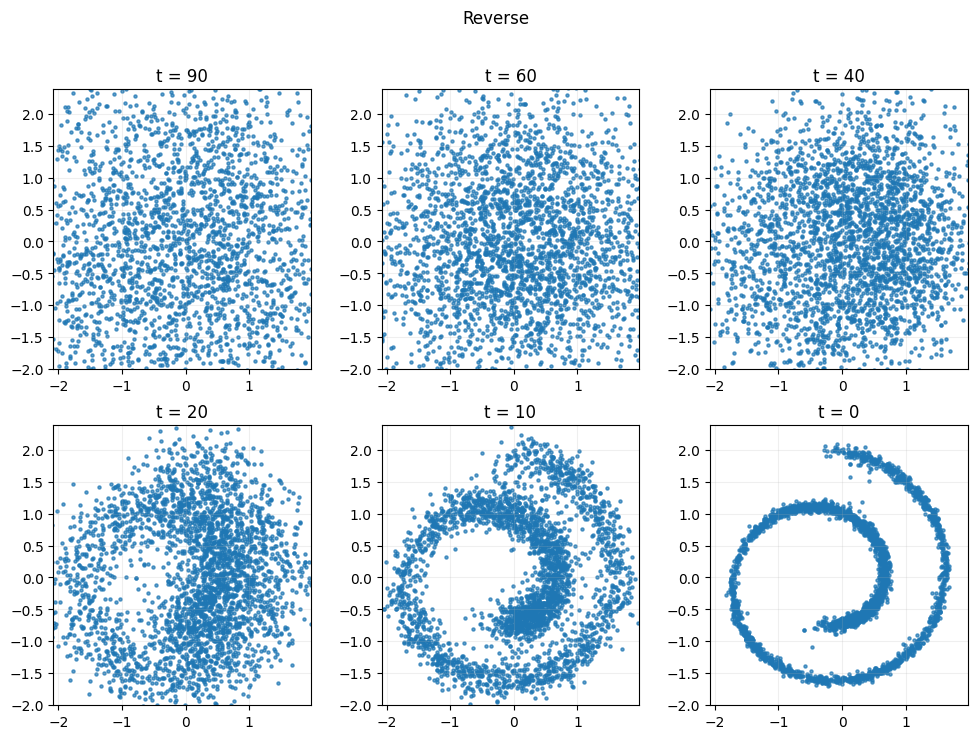

In [13]:
model.eval()

# Show snapshots at a few time steps during reverse denoising
plot_reverse_grid(
    model,
    steps=[10, 20, 40, 60, 90 ],
    ref_points=dataset.data,
    n_show=3000,
    cols=3,
    title="Reverse",
)

**Instructor note:** Just run this cell, you can ignore the code details.

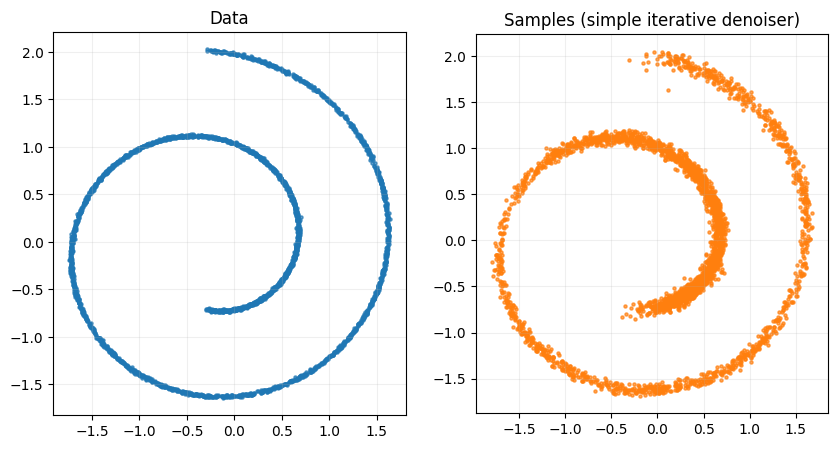

In [14]:
# Draw new samples from the model
with torch.no_grad():
    samples, _ = model.sample(n=5000, step_size=0.9, eta=0.8, collect_ts=None)
    samples = samples.cpu()

# Compare data vs generated samples
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(dataset.data[:3000, 0], dataset.data[:3000, 1], s=5, alpha=0.7)
plt.title("Data")
ax = plt.gca()
ax.set_aspect("equal", "box")
plt.grid(alpha=0.2)

plt.subplot(1, 2, 2)
plt.scatter(samples[:3000, 0], samples[:3000, 1],
            s=5, alpha=0.7, color="tab:orange")
plt.title("Samples (simple iterative denoiser)")
ax = plt.gca()
ax.set_aspect("equal", "box")
plt.grid(alpha=0.2)
plt.show()

## FAQ and tips

- Why predict noise instead of clean data
  - Predicting $\epsilon$ makes the problem well-scaled and avoids difficulties from predicting $x_0$ directly.
- What is $\sigma(t)$
  - It is the noise strength at time $t$. We use a simple linear schedule from 0 to $\sigma_{\max}$.
- What happens if I change $T$
  - Higher $T$ gives more, smaller steps. This can help stability but costs more compute.
- What happens if I change step_size and eta in sampling
  - Larger step_size denoises faster but can overshoot.
  - Larger eta adds randomness and can increase sample diversity.
